In [1]:
#Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')


In [3]:
#Loading dataset obtained from Kaggel

In [4]:
df = pd.read_csv('../data/healthcare_analytics_patient_flow_data.csv')

In [5]:
#Convert Date & Time Data Types

In [6]:
df['Patient Admission Date'] = pd.to_datetime(df['Patient Admission Date'], format='%d/%m/%Y')
df['Patient Admission Time'] = pd.to_datetime(df['Patient Admission Time'], format='%I:%M:%S %p').dt.time

df['Admission Datetime'] = pd.to_datetime(
    df['Patient Admission Date'].astype(str) + ' ' + df['Patient Admission Time'].astype(str)
)

In [7]:
#Clean Wait times

In [8]:
df['Patient Waittime'] = pd.to_numeric(df['Patient Waittime'], errors='coerce')
df['Patient Waittime'].fillna(df['Patient Waittime'].median(), inplace=True)

In [9]:
#Clean Satisfaction Score

In [10]:
df['Patient Satisfaction Score'] = df['Patient Satisfaction Score'].fillna(
    df['Patient Satisfaction Score'].median()
)

In [11]:
#Clean department referrals

In [12]:
df['Department Referral'] = df['Department Referral'].fillna('Unassigned')

In [13]:
#Clean Gender Column

In [14]:
df['Patient Gender'] = df['Patient Gender'].str.strip().replace('Femaleemale', 'Female')

In [15]:
#Data Inspection

In [16]:
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
print(f"Date range: {df['Patient Admission Date'].min().date()} → {df['Patient Admission Date'].max().date()}")
print(f"Null satisfaction scores remaining: {df['Patient Satisfaction Score'].isna().sum()}")
print(f"Null wait times remaining: {df['Patient Waittime'].isna().sum()}")
print(f"\nSatisfaction Score — mean: {df['Patient Satisfaction Score'].mean():.2f}, median: {df['Patient Satisfaction Score'].median():.2f}")

Loaded 9,216 rows × 12 columns
Date range: 2023-04-01 → 2024-10-30
Null satisfaction scores remaining: 0
Null wait times remaining: 0

Satisfaction Score — mean: 5.00, median: 5.00


In [17]:
#Feature Engineering

In [18]:
#Copy cleaned dataframe
cleaned_df = df.copy()

#Datetime components
cleaned_df['Admission Year'] = cleaned_df['Admission Datetime'].dt.year
cleaned_df['Admission Month'] = cleaned_df['Admission Datetime'].dt.month
cleaned_df['Admission Day'] = cleaned_df['Admission Datetime'].dt.day
cleaned_df['Admission Hour'] = cleaned_df['Admission Datetime'].dt.hour
cleaned_df['Admission Day of Week'] = cleaned_df['Admission Datetime'].dt.day_name()

#Age Groups
age_bins = [0, 5, 13, 18, 40, 65, float('inf')]
age_labels = ['1-4', '5-12', '13-17', '18-39', '40-64', '65+']

cleaned_df['Age Group'] = pd.cut(
    cleaned_df['Patient Age'], 
    bins = age_bins, 
    labels = age_labels, 
    right = False
)

#Wait time categories
time_bins = [0, 10, 20, 30, 40, 50, float('inf')]
time_labels = ['0-10 min', '10-20 min', '20-30 min', '30-40 min', '40-50 min', '50+ min']

cleaned_df['Wait Time Category'] = pd.cut(
    cleaned_df['Patient Waittime'], 
    bins = time_bins, 
    labels = time_labels, 
    right = False
)

#Mapping Admission Flags
cleaned_df['Patient Admission Flag'] = cleaned_df['Patient Admission Flag'].map({'Admission': 1, 'Not Admission': 0})

In [19]:
#Data Inspection

In [20]:
print(f"cleaned_df shape: {cleaned_df.shape}")
print(f"\nNew columns added: {[c for c in cleaned_df.columns if c not in df.columns]}")
print(f"\nAge Group distribution:\n{cleaned_df['Age Group'].value_counts().sort_index()}")
print(f"\nWait Time Category distribution:\n{cleaned_df['Wait Time Category'].value_counts().sort_index()}")

cleaned_df shape: (9216, 19)

New columns added: ['Admission Year', 'Admission Month', 'Admission Day', 'Admission Hour', 'Admission Day of Week', 'Age Group', 'Wait Time Category']

Age Group distribution:
Age Group
1-4       464
5-12      949
13-17     558
18-39    2652
40-64    2857
65+      1736
Name: count, dtype: int64

Wait Time Category distribution:
Wait Time Category
0-10 min        0
10-20 min    1771
20-30 min    1761
30-40 min    1817
40-50 min    1831
50+ min      2036
Name: count, dtype: int64


In [21]:
#Exploratory Data Analysis

In [22]:
#Variables
#Daily patient volume
daily_volume = cleaned_df.groupby('Patient Admission Date').size().reset_index(name='Volume')

#Hourly patient volume
hourly_volume = cleaned_df.groupby('Admission Hour').size().reset_index(name='Volume')

#Wait time distribution (counts per category)
wait_time_dist = cleaned_df['Wait Time Category'].value_counts().sort_index()

#Average wait time by department
wait_time_by_dept = (
    cleaned_df.groupby('Department Referral')['Patient Waittime']
    .agg(['mean', 'median', 'std'])
    .reset_index()
    .sort_values('mean', ascending=False)
)

#Satisfaction vs wait time scatter + trendline coefficients
scatter_data = cleaned_df.groupby('Patient Waittime')['Patient Satisfaction Score'].mean().reset_index()
_z = np.polyfit(scatter_data['Patient Waittime'], scatter_data['Patient Satisfaction Score'], 1)
trendline_poly = np.poly1d(_z)

#Admission rate by hour of day
admission_rate_by_hour = (
    cleaned_df.groupby('Admission Hour')['Patient Admission Flag']
    .agg(['sum', 'count'])
    .reset_index()
)
admission_rate_by_hour.columns = ['Admission Hour', 'Admissions', 'Total']
admission_rate_by_hour['Admission Rate'] = (
    admission_rate_by_hour['Admissions'] / admission_rate_by_hour['Total'] * 100
).round(2)

#Satisfaction score by age group
satisfaction_by_age = (
    cleaned_df.groupby('Age Group', observed=True)['Patient Satisfaction Score']
    .agg(['mean', 'median', 'std'])
    .reset_index()
)

#Correlation matrix
correlation_matrix = cleaned_df[
    ['Patient Waittime', 'Patient Satisfaction Score', 'Patient Admission Flag', 'Patient Age']
].corr()

#Admission flag distribution
admission_flag_counts = cleaned_df['Patient Admission Flag'].value_counts().reset_index()
admission_flag_counts.columns = ['Admission Flag', 'Count']
admission_flag_counts['Label'] = admission_flag_counts['Admission Flag'].map({1: 'Admission', 0: 'Not Admission'})

#Summary
print("=== PATIENT FLOW DATA SUMMARY ===")
print(f"Total patients:       {len(cleaned_df):,}")
print(f"Date range:           {cleaned_df['Patient Admission Date'].min().date()} → {cleaned_df['Patient Admission Date'].max().date()}")
print(f"Admission rate:       {(cleaned_df['Patient Admission Flag'].sum() / len(cleaned_df) * 100):.2f}%")
print(f"Avg wait time:        {cleaned_df['Patient Waittime'].mean():.2f} min")
print(f"Avg satisfaction:     {cleaned_df['Patient Satisfaction Score'].mean():.2f} / 10")
print(f"\nWait time percentiles:\n{cleaned_df['Patient Waittime'].describe().round(2)}")
print(f"\nSatisfaction score percentiles:\n{cleaned_df['Patient Satisfaction Score'].describe().round(2)}")
print(f"\nPatients by department:\n{cleaned_df['Department Referral'].value_counts()}")

=== PATIENT FLOW DATA SUMMARY ===
Total patients:       9,216
Date range:           2023-04-01 → 2024-10-30
Admission rate:       50.04%
Avg wait time:        35.26 min
Avg satisfaction:     5.00 / 10

Wait time percentiles:
count    9216.00
mean       35.26
std        14.74
min        10.00
25%        23.00
50%        35.00
75%        48.00
max        60.00
Name: Patient Waittime, dtype: float64

Satisfaction score percentiles:
count    9216.00
mean        5.00
std         1.64
min         0.00
25%         5.00
50%         5.00
75%         5.00
max        10.00
Name: Patient Satisfaction Score, dtype: float64

Patients by department:
Department Referral
Unassigned          5400
General Practice    1840
Orthopedics          995
Physiotherapy        276
Cardiology           248
Neurology            193
Gastroenterology     178
Renal                 86
Name: count, dtype: int64


In [23]:
#Visualizations

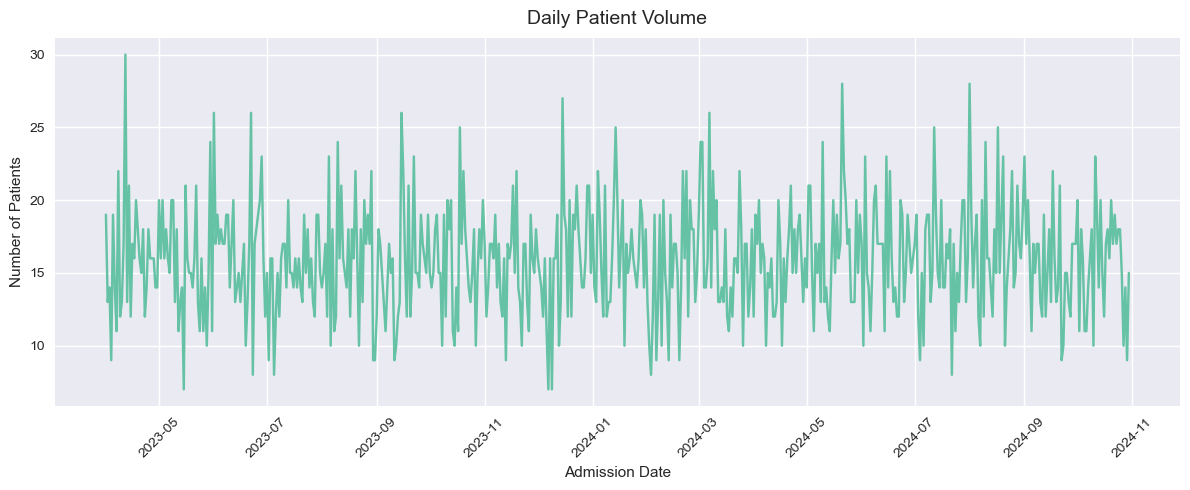

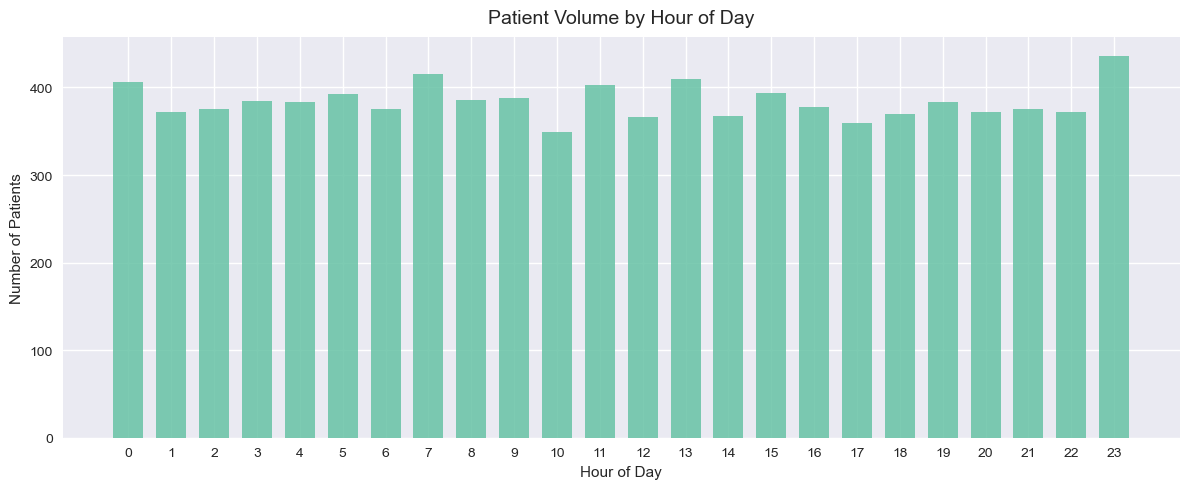

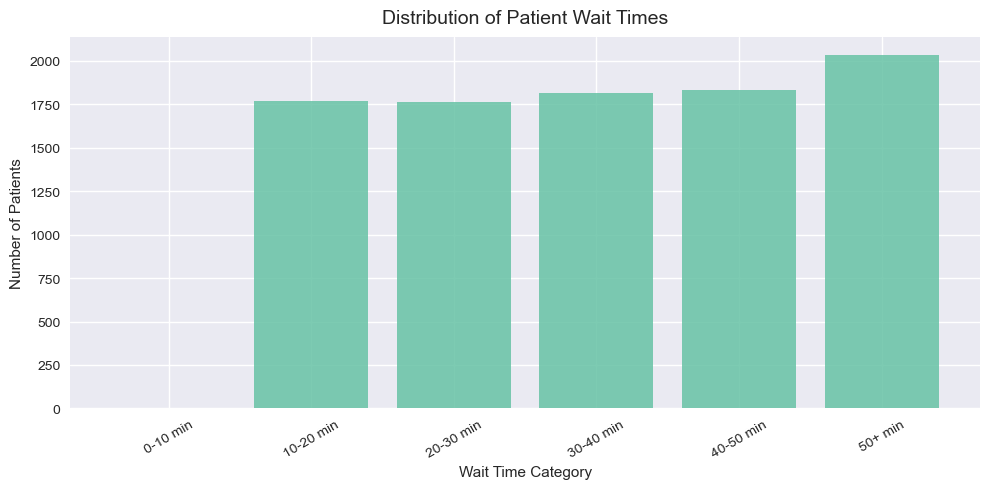

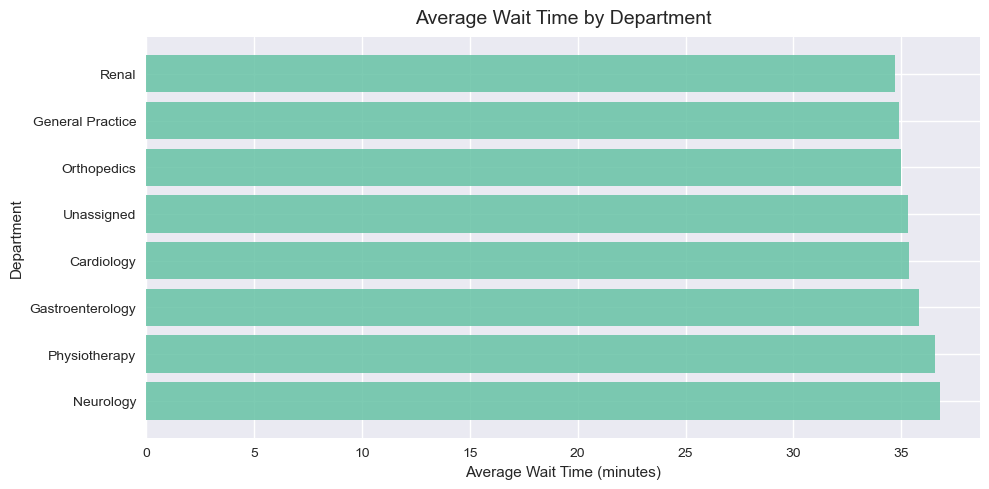

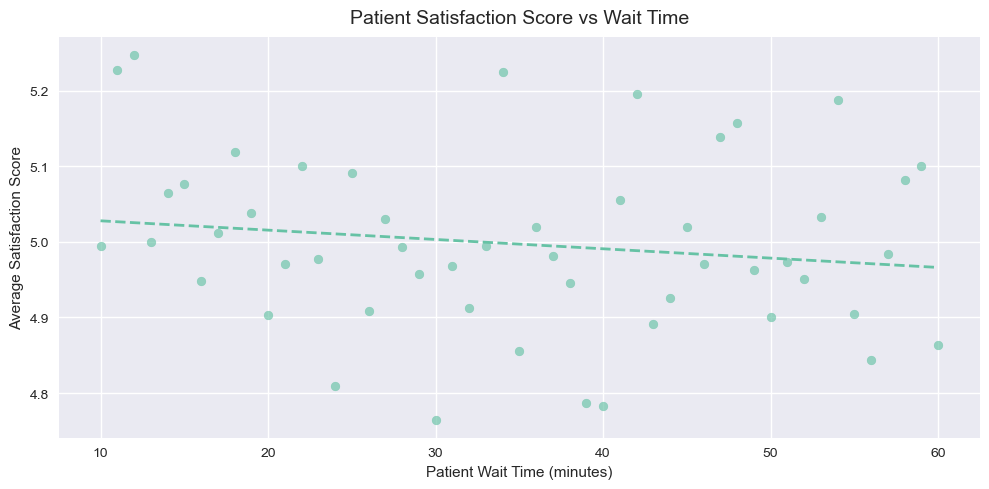

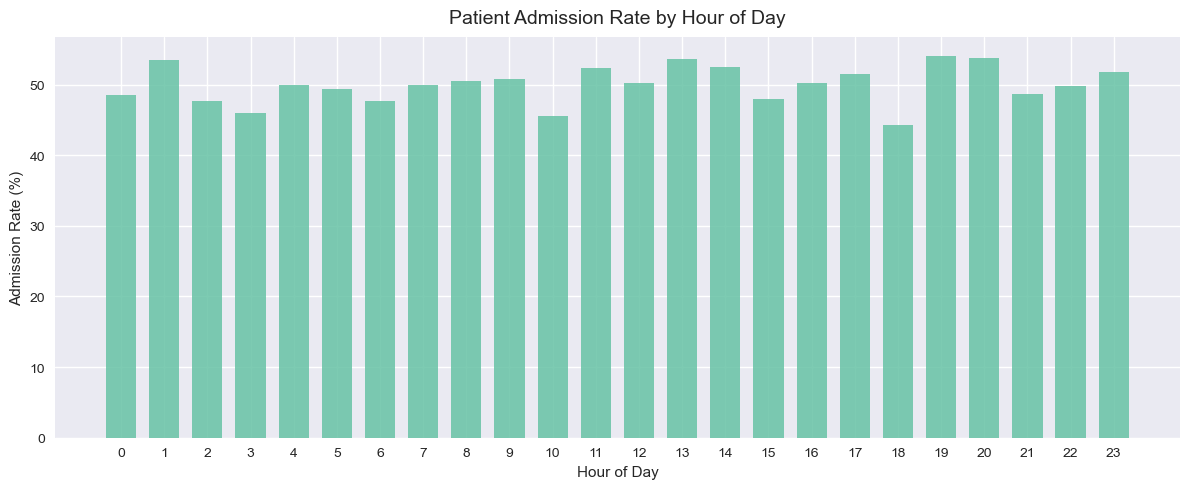

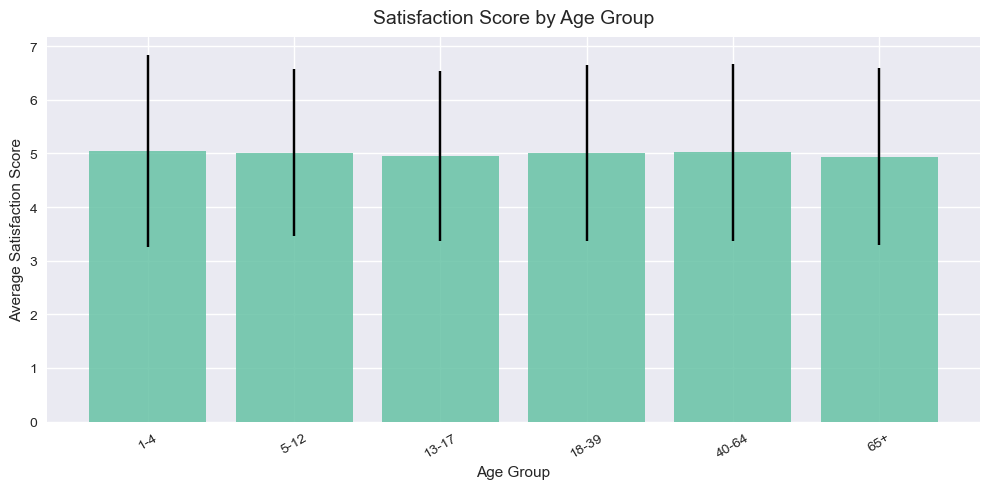

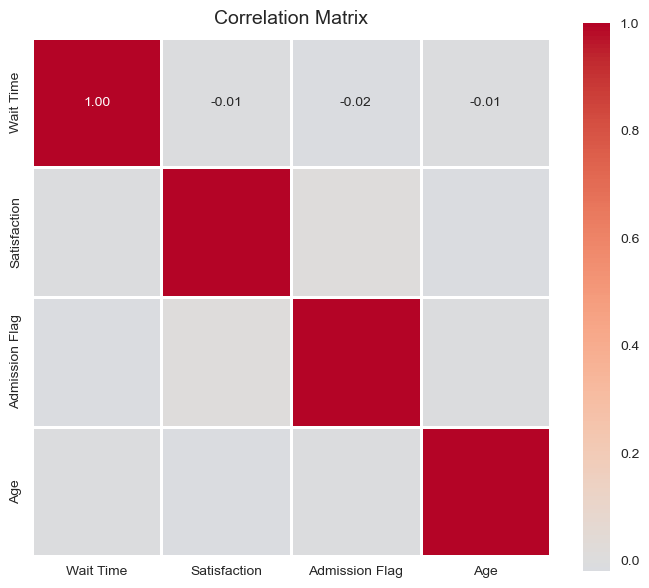

In [24]:
#Patient Volume Over Time
fig_daily_volume, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_volume['Patient Admission Date'], daily_volume['Volume'])
ax.set_title('Daily Patient Volume', fontsize=14, pad=10)
ax.set_xlabel('Admission Date')
ax.set_ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Volume by Hour of Day
fig_hourly_volume, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly_volume['Admission Hour'], hourly_volume['Volume'], alpha=0.85, width=0.7)
ax.set_title('Patient Volume by Hour of Day', fontsize=14, pad=10)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Patients')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

#Wait Time Distribution
fig_wait_dist, ax = plt.subplots(figsize=(10, 5))
_labels = [str(l) for l in wait_time_dist.index]
ax.bar(_labels, wait_time_dist.values, alpha=0.85)
ax.set_title('Distribution of Patient Wait Times', fontsize=14, pad=10)
ax.set_xlabel('Wait Time Category')
ax.set_ylabel('Number of Patients')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#Average Wait Time by Department
fig_wait_dept, ax = plt.subplots(figsize=(10, 5))
ax.barh(wait_time_by_dept['Department Referral'], wait_time_by_dept['mean'], alpha=0.85)
ax.set_title('Average Wait Time by Department', fontsize=14, pad=10)
ax.set_xlabel('Average Wait Time (minutes)')
ax.set_ylabel('Department')
plt.tight_layout()
plt.show()

#Satisfaction vs Wait Time
fig_satisfaction_vs_wait, ax = plt.subplots(figsize=(10, 5))
ax.scatter(scatter_data['Patient Waittime'], scatter_data['Patient Satisfaction Score'],
           alpha=0.65, s=40, label='Avg Score')
_x = scatter_data['Patient Waittime']
ax.plot(_x, trendline_poly(_x), '--', linewidth=2, label='Trendline')
ax.set_title('Patient Satisfaction Score vs Wait Time', fontsize=14, pad=10)
ax.set_xlabel('Patient Wait Time (minutes)')
ax.set_ylabel('Average Satisfaction Score')
plt.tight_layout()
plt.show()

#Admission Rate by Hour
fig_admission_rate, ax = plt.subplots(figsize=(12, 5))
ax.bar(admission_rate_by_hour['Admission Hour'], admission_rate_by_hour['Admission Rate'], alpha=0.85, width=0.7)
ax.set_title('Patient Admission Rate by Hour of Day', fontsize=14, pad=10)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Admission Rate (%)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

#Wait Time by Age Group
fig_satisfaction_age, ax = plt.subplots(figsize=(10, 5))
_x_pos = range(len(satisfaction_by_age))
ax.bar(_x_pos, satisfaction_by_age['mean'], alpha=0.85, yerr=satisfaction_by_age['std'], capsize=5)
ax.set_title('Satisfaction Score by Age Group', fontsize=14, pad=10)
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Satisfaction Score')
ax.set_xticks(list(_x_pos))
ax.set_xticklabels([str(g) for g in satisfaction_by_age['Age Group']], rotation=30)
plt.tight_layout()
plt.show()

#Correlation Heatmap

fig_correlation, ax = plt.subplots(figsize=(7, 6))
_labels = ['Wait Time', 'Satisfaction', 'Admission Flag', 'Age']
sns.heatmap(
    correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=1, ax=ax,
    xticklabels=_labels, yticklabels=_labels
)
ax.set_title('Correlation Matrix', fontsize=14, pad=10)
plt.tight_layout()
plt.show()

In [25]:
#Export Cleaned Data as CSV for Visualization Dashborad
file_path = "../data/cleaned_healthcare_analytics_patient_flow_data.csv"

try:
    # Export DataFrame to CSV
    # index=False prevents writing row numbers
    df.to_csv(file_path, index=False, encoding="utf-8-sig")

    # Confirm file creation
    if os.path.exists(file_path):
        print(f"DataFrame successfully exported to '{file_path}'")
    else:
        print("Error: File was not created.")

except (OSError, IOError) as e:
    print(f"File write error: {e}")

except Exception as e:
    print(f"Unexpected error: {e}")

DataFrame successfully exported to '../data/cleaned_healthcare_analytics_patient_flow_data.csv'
